# Modeling — Whiff LR (`is_whiff`)

Logistic-regression **control model** for whiff probability **conditional on a swing**.

**Prerequisites:** `03_feature_engineering.ipynb` → `04_modeling_swing_logr.ipynb`

Production counterpart: **`07_modeling_whiff_rf.ipynb`**.

## 1. Target definition

**Target:** `is_whiff` (binary), evaluated on rows with **`is_swing = 1`** only.

## Architecture — apples-to-apples control for RF models

These **logistic / linear baselines** use the **same feature space, pitch-type schema, and chronological split** as the production Random Forest pipeline (`05`, `07`, `09`).

| Split | Dates | Purpose |
|-------|-------|---------|
| **Train** | Mar–Jul 2025 (`game_date < 2025-08-01`) | Fit models |
| **Validation** | Aug 2025 | Forward feature-group selection only |
| **Test** | Sep 2025 | Locked holdout — final metrics once |

**Batter signal:** season-to-date rolling metrics (`swing_pct`, `whiff_pct`, `z_swing_pct`, `o_swing_pct`, `z_whiff_pct`, `o_whiff_pct`) — no `batter_id` or `batter_te`.

**Platoon:** `same_handed`

**Pitch physics (three groups):** `pitch_movement` (`norm_hb`, `norm_ivb`) → `pitcher_delivery` (release point, extension, `p_throws_L`) → `pitch_quality` (`release_speed`, `release_spin_rate`).

**Pitch types:** all **10** competitive Statcast codes (`COMPETITIVE_PITCH_TYPES`) via one-hot `pitch_*` columns.

**Swing definition:** full swings only — `foul_bunt` and `missed_bunt` are takes, not swings.


## 2. Process

| Step | Choice |
|------|--------|
| **Sample** | Swings only |
| **Baseline features** | `is_in_zone`, `miss_dist_in`, `center_dist_in` |
| **Candidate groups** | `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `bat_tracking` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon` |
| **Selection metric** | August validation log-loss; keep if gain ≥ **MIN_GAIN (0.0010)** |
| **Group order** | High-signal sequence with `bat_tracking` after `batter_rolling` |
| **Final evaluation** | September test once |

Logic: `src/whiff_modeling.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODELING_FILE = ROOT / "data" / "modeling_frame_2025.parquet"
if not MODELING_FILE.exists():
    raise FileNotFoundError(
        f"Run 03_feature_engineering.ipynb first — missing {MODELING_FILE}"
    )

import importlib
import src.feature_engineering as feature_engineering
import src.swing_modeling as swing_modeling
import src.whiff_modeling as whiff_modeling

importlib.reload(feature_engineering)
importlib.reload(swing_modeling)
importlib.reload(whiff_modeling)

from src.whiff_modeling import (
    BASELINE_FEATURES,
    FEATURE_GROUP_ORDER,
    FEATURE_GROUPS,
    TARGET,
    TRAIN_END,
    VAL_END,
    calibration_bins,
    chronological_split,
    coefficient_frame,
    forward_select_feature_groups,
    results_table,
    roc_curve_data,
    swings_only,
    whiff_target_definition,
    train_master_model,
)

frame = pd.read_parquet(MODELING_FILE)
train, val, test = chronological_split(frame)
train_sw = swings_only(train)
val_sw = swings_only(val)
test_sw = swings_only(test)

display(Markdown(whiff_target_definition()))
print(f"Swings — train: {len(train_sw):,} | val: {len(val_sw):,} | test: {len(test_sw):,}")
print(f"Whiff rate — train: {train_sw[TARGET].mean():.1%} | val: {val_sw[TARGET].mean():.1%} | test: {test_sw[TARGET].mean():.1%}")
print(f"Train: Mar–Jul (< {TRAIN_END.date()}) | Val: Aug | Test: Sep (>= {VAL_END.date()})")


is_whiff = 1 when Statcast description is a whiff (swinging_strike, swinging_strike_blocked); else 0. Evaluated on **swings only** (`is_swing = 1`). Bunts are not swings.

Swings — train: 221,344 | val: 57,919 | test: 51,768
Whiff rate — train: 22.9% | val: 23.2% | test: 24.3%
Train: Mar–Jul (< 2025-08-01) | Val: Aug | Test: Sep (>= 2025-09-01)


## 3. Baseline & candidate groups

In [2]:
print("Baseline features:", BASELINE_FEATURES)
print("\nCandidate groups (added one at a time; includes bat_tracking):")
for name in FEATURE_GROUP_ORDER:
    print(f"  • {name}: {len(FEATURE_GROUPS[name])} columns")
    if name in ("batter_rolling", "bat_tracking"):
        print(f"      {FEATURE_GROUPS[name]}")


Baseline features: ['is_in_zone', 'miss_dist_in', 'center_dist_in']

Candidate groups (added one at a time; includes bat_tracking):
  • pitch_type: 10 columns
  • pitch_quality: 2 columns
  • count: 12 columns
  • batter_rolling: 6 columns
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
  • bat_tracking: 3 columns
      ['bat_speed', 'attack_angle', 'squared_up_rate']
  • pitch_movement: 2 columns
  • pitcher_delivery: 5 columns
  • attack_zone: 4 columns
  • base_state: 8 columns
  • platoon: 1 columns


## 4. Forward selection + September test evaluation

In [3]:
MIN_GAIN = 0.0010

print(f"Minimum gain threshold: {MIN_GAIN:.4f} log-loss\n")
report = forward_select_feature_groups(
    train,
    val,
    min_log_loss_gain=MIN_GAIN,
    verbose=True,
)

baseline_master = train_master_model(train, test, BASELINE_FEATURES, name="baseline (Sep test)")
master = train_master_model(train, test, report.final.features, name="final (Sep test)")

print("\nSelected groups:", report.selected_groups or "(baseline only)")
print(f"Final feature count: {len(report.final.features)}")
print(
    f"Baseline test — log-loss: {baseline_master.test_log_loss:.4f} | "
    f"ROC-AUC: {baseline_master.test_roc_auc:.3f}"
)
print(
    f"Final test — log-loss: {master.test_log_loss:.4f} | "
    f"ROC-AUC: {master.test_roc_auc:.3f} | "
    f"Brier: {master.test_brier:.4f}"
)

display(results_table(report))


Minimum gain threshold: 0.0010 log-loss

Baseline — val log-loss: 0.5938 (3 features)
  pitch_type: Kept (log-loss gain = +0.0060, val log-loss = 0.5878, 13 features)
  pitch_quality: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0002)
  count: Kept (log-loss gain = +0.0067, val log-loss = 0.5812, 25 features)
  batter_rolling: Kept (log-loss gain = +0.0092, val log-loss = 0.5719, 31 features)
  bat_tracking: Kept (log-loss gain = +0.0017, val log-loss = 0.5702, 34 features)
  pitch_movement: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0002)
  pitcher_delivery: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0001)
  attack_zone: Kept (log-loss gain = +0.0010, val log-loss = 0.5692, 38 features)
  base_state: Dropped due to insufficient gain (< 0.0010) (log-loss gain = -0.0001)
  platoon: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0006)

Selected groups: ['pitch_type', 'count', 'batter_rolling', 'bat_tracking', '

,step,added_group,kept,n_features,val_log_loss,val_roc_auc,delta_log_loss
0,baseline,None,yes,3,0.5938,0.728,+0.0000
1,pitch_type,pitch_type,yes,13,0.5878,0.737,+0.0060
2,pitch_quality,pitch_quality,no,15,0.5876,0.738,+0.0002
3,count,count,yes,25,0.5812,0.743,+0.0067
4,batter_rolling,batter_rolling,yes,31,0.5719,0.753,+0.0092
5,bat_tracking,bat_tracking,yes,34,0.5702,0.754,+0.0017
6,pitch_movement,pitch_movement,no,36,0.5701,0.755,+0.0002
7,pitcher_delivery,pitcher_delivery,no,39,0.5702,0.753,+0.0001
8,attack_zone,attack_zone,yes,38,0.5692,0.755,+0.0010
9,base_state,base_state,no,46,0.5693,0.755,-0.0001


## 5. Visuals

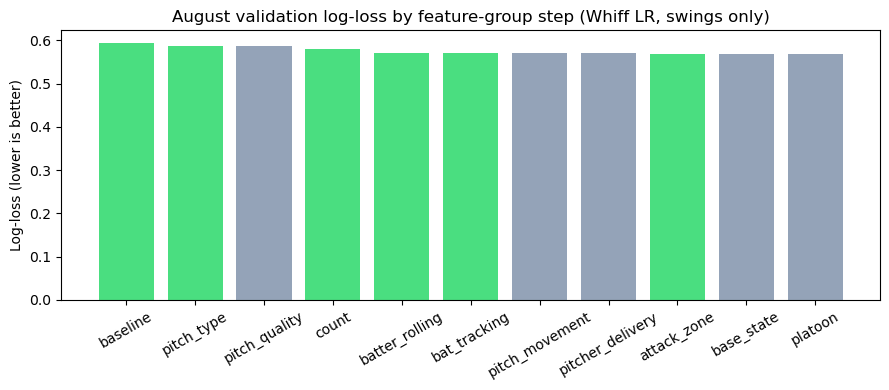

In [4]:
steps_df = pd.DataFrame(report.steps)
colors = ["#4ade80" if kept else "#94a3b8" for kept in steps_df["kept"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(steps_df["step"], steps_df["val_log_loss"], color=colors)
ax.set_title("August validation log-loss by feature-group step (Whiff LR, swings only)")
ax.set_ylabel("Log-loss (lower is better)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


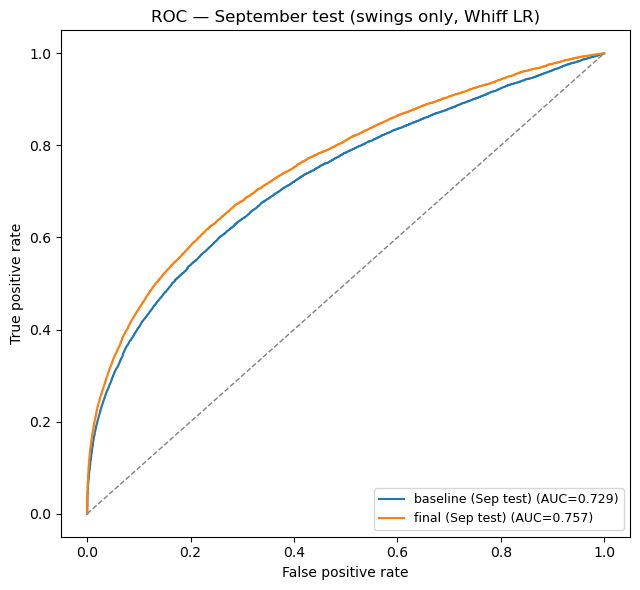

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result in [baseline_master, master]:
    fpr, tpr = roc_curve_data(result)
    ax.plot(fpr, tpr, label=f"{result.name} (AUC={result.test_roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_title("ROC — September test (swings only, Whiff LR)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()


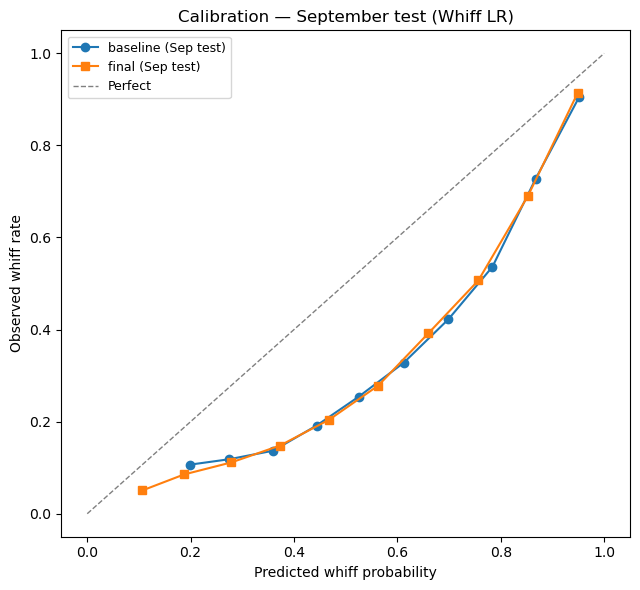

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result, style in [(baseline_master, "o-"), (master, "s-")]:
    cal = calibration_bins(result.y_test, result.y_prob_test)
    ax.plot(cal["pred_mean"], cal["obs_rate"], style, label=result.name)
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Perfect")
ax.set_title("Calibration — September test (Whiff LR)")
ax.set_xlabel("Predicted whiff probability")
ax.set_ylabel("Observed whiff rate")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()


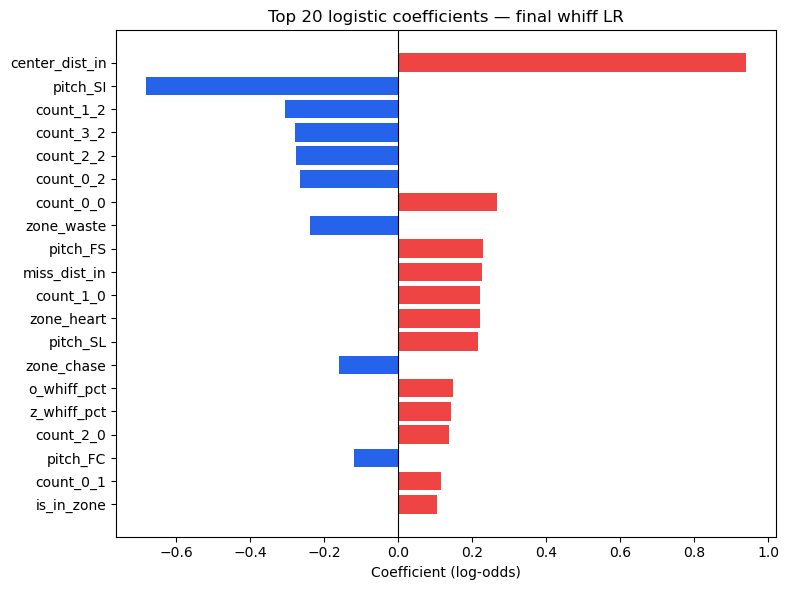

,feature,coefficient,abs_coef
0,center_dist_in,0.939209,0.939209
1,pitch_SI,-0.680956,0.680956
2,count_1_2,-0.306833,0.306833
3,count_3_2,-0.278544,0.278544
4,count_2_2,-0.276556,0.276556
5,count_0_2,-0.266038,0.266038
6,count_0_0,0.265822,0.265822
7,zone_waste,-0.239990,0.239990
8,pitch_FS,0.229478,0.229478
9,miss_dist_in,0.224766,0.224766


In [7]:
coef = coefficient_frame(master).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#ef4444" if c > 0 else "#2563eb" for c in coef["coefficient"]]
ax.barh(coef["feature"][::-1], coef["coefficient"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 logistic coefficients — final whiff LR")
ax.set_xlabel("Coefficient (log-odds)")
fig.tight_layout()
plt.show()

display(coef)


## 6. Summary

Compare September test metrics to **`07_modeling_whiff_rf.ipynb`**. Next: **`08_modeling_xwobacon_lr.ipynb`**.